In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Training as a function of the number of temporal jitter

In [9]:
import torch
from wassa_functions import performance_as_a_function_of_dataset_parameters
from wassa_plots import plot_results_std
import matplotlib.pyplot as plt

In [10]:
date = '2025-08-19'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
device = 'cuda:1'

In [12]:
dataset_parameters = {
    'seed' : 666,
    
    'N_pre' : 150, # number of neurons
    'N_timesteps' : 255, # number of timesteps for the raster plot (in ms)
    'N_samples' : 60, # total number of samples in the dataset

    'N_delays' : 51, # number of timesteps in spiking motifs, must be a odd number for convolutions
    'N_SMs' : 1, # number of structured spiking motifs
    'avg_fr' : 20, # average firing rate of the neurons (in Hz)
    'std_fr' : .1, # standard deviation for the firing rates of the different neurons
    'overlapping_sms' : False, # possibility to have overlapping sequences

    'temporal_jitter' : .1, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : .1, # percentage of background noise/spontaneous activity
    'warping_coef' : 1, # coefficient for time warping

}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_SMs'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'frs' : torch.normal(dataset_parameters['avg_fr'], dataset_parameters['std_fr'], size=(dataset_parameters['N_pre'],)).abs()})
dataset_parameters.update({'freq_sms' : 10*torch.ones(dataset_parameters['N_SMs'])}) # frequency of apparition of the different spiking motifs (in Hz)
dataset_parameters.update({'coefficient_variation' : 1*torch.ones(dataset_parameters['N_pre'],device=device)}) # coefficient of variation of the FRs of each neuron (within VS. without a motif)

In [13]:
training_parameters = {
    'kernel_size' : (dataset_parameters['N_SMs'], dataset_parameters['N_pre'], dataset_parameters['N_delays']),
    'loss_type' : 'mse',
    'N_learnsteps' : 1000,
    'learning_rate' : .05,
    'beta_1' : .9,
    'penalty_type' : [None],
    'smoothwind' : 0,
    'expected_patterns_per_sample' : dataset_parameters['N_timesteps']*dataset_parameters['freq_sms'][0]*1e-3,
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : [False,False,False],
    'tied_weights' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
    'reshape_input': True}

In [7]:
dataset_variables = {
'temporal_jitter' : torch.linspace(.1,20,10).tolist(),
}

In [8]:
file_name = 'trial_jitter'
training_metrics = ['training loss', 'testing loss', 'explained variance', 'kernels correlation', 'train/test factors difference']
synthetic_metrics = ['factors similarity', 'kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings']
n_iter = 20
kfold = 3
do_seqnmf = False
results, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, verbose=True, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

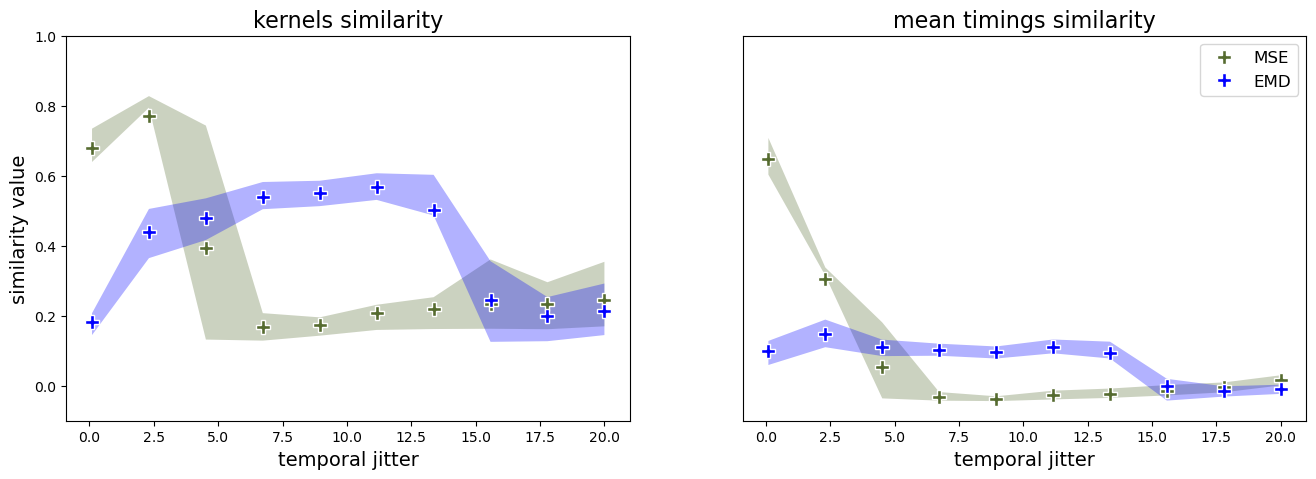

In [9]:
name_metrics = ['kernels similarity', 'mean timings similarity']
name_methods = ['MSE', 'EMD']
colors = ['darkolivegreen','blue','purple','orangered']
xlabel = 'temporal jitter'

results = results.cpu()
fig, ax = plt.subplots(1,2, figsize=(16,5))
for i in range(len(name_metrics)):
    for m in range(len(name_methods)):
        if i==0:
            do_ylabel = True
        else:
            do_ylabel = False
        if i == 0:
            ymin = -.1
        else:
            ymin = 0
        if i == 1:
            do_legend = True
        else:
            do_legend = False
        ax[i] = plot_results_std(ax[i],results[:,m],dataset_variables['temporal_jitter'],training_metrics+synthetic_metrics,xlabel,name_metrics[i],name_methods[m],colors[m],ymax=1,ymin=ymin,do_ylabel=do_ylabel,do_legend=do_legend,quantile=True)